# cVAE Post-Training Analysis for AMP Generation

This notebook performs post-training analysis of the conditional VAE trained for antimicrobial peptide generation.

Main goals:
1. load the saved cVAE checkpoint and artifacts,
2. reproduce the exact dataset split used during training,
3. evaluate reconstruction and generation quality,
4. compare real and generated peptides,
5. analyze physicochemical properties,
6. inspect latent-space structure with t-SNE,
7. visualize interpolation trajectories,
8. save summary tables for the final report.

This notebook is analysis-only: it does not retrain the model and relies on artifacts saved by `cvae_training.ipynb`.

In [1]:
import os
import json
import math
import pickle
import random
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [3]:
# ------------------------------------------------------------------
# Reproducibility and path resolution
# ------------------------------------------------------------------
SEED = 42
# Reuse the same seed as in training so any subsampling or visualization
# choices in this notebook remain reproducible across runs.
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

def first_existing(paths):
    for p in paths:
        p = Path(p)
        if p.exists():
            return p
    raise FileNotFoundError("None of the candidate paths exists:\n" + "\n".join(map(str, paths)))

# Resolve paths robustly so the notebook can be executed either from the
# repository root or from the notebooks directory without manual edits.
DATA_PATH = first_existing([
    Path("Data/processed/master_dataset.csv"),
    Path("../../Data/processed/master_dataset.csv"),
    Path("../Data/processed/master_dataset.csv"),
])

ARTIFACTS_DIR = first_existing([
    Path("../models_artifacts"),
    Path("../../model_training/models_artifacts"),
    Path("model_training/models_artifacts"),
])

VOCAB_PATH = ARTIFACTS_DIR / "vocab.pkl"
CONFIG_PATH = ARTIFACTS_DIR / "cvae_config.json"
MODEL_PATH = ARTIFACTS_DIR / "best_cvae.pt"
HISTORY_PATH = ARTIFACTS_DIR / "training_history.pkl"
SPLITS_PATH = ARTIFACTS_DIR / "split_indices.pkl"

# Store derived tables and plots separately from model checkpoints.
# This keeps training artifacts and analysis outputs clearly separated.
OUTPUT_DIR = Path("analysis_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

Using device: cpu


## 1. Load dataset and saved artifacts

### Why we reload saved artifacts

To avoid evaluation drift, this notebook reconstructs the exact tokenizer, maximum sequence length, and train/validation/test split used during training.

This is important because even small differences in tokenization or split composition can change reconstruction metrics and latent-space plots.

In [4]:
with open(VOCAB_PATH, "rb") as f:
    vocab_artifacts = pickle.load(f)

with open(CONFIG_PATH, "r") as f:
    config = json.load(f)

history = None
if HISTORY_PATH.exists():
    with open(HISTORY_PATH, "rb") as f:
        history = pickle.load(f)

split_indices = None
if SPLITS_PATH.exists():
    with open(SPLITS_PATH, "rb") as f:
        split_indices = pickle.load(f)

char2idx = vocab_artifacts["char2idx"]
idx2char = {int(k): v for k, v in vocab_artifacts["idx2char"].items()} if isinstance(next(iter(vocab_artifacts["idx2char"].keys())), str) else vocab_artifacts["idx2char"]
max_len = int(vocab_artifacts["max_len"])
vocab_size = len(char2idx)

PAD_IDX = char2idx["<PAD>"]
SOS_IDX = char2idx["<SOS>"]
EOS_IDX = char2idx["<EOS>"]
UNK_IDX = char2idx["<UNK>"]

seq_col = config.get("seq_col", "Sequence")
len_col = config.get("len_col", "Length")
condition_cols = config.get(
    "condition_cols",
    [
        "is_antibacterial", "is_anti_gram_positive", "is_anti_gram_negative",
        "is_antifungal", "is_antiviral", "is_antiparasitic", "is_anticancer"
    ],
)

pretty_condition_names = {
    "is_antibacterial": "Antibacterial",
    "is_anti_gram_positive": "Gram+",
    "is_anti_gram_negative": "Gram-",
    "is_antifungal": "Antifungal",
    "is_antiviral": "Antiviral",
    "is_antiparasitic": "Antiparasitic",
    "is_anticancer": "Anticancer",
}

df = pd.read_csv(DATA_PATH)

keep_cols = [c for c in [seq_col, len_col] + condition_cols if c in df.columns]
df = df[keep_cols].dropna(subset=[seq_col]).copy()

canonical_aas = set("ACDEFGHIKLMNPQRSTVWY")
df[seq_col] = df[seq_col].astype(str).str.upper()
df = df[df[seq_col].map(lambda s: all(ch in canonical_aas for ch in s))]

# Deduplication is repeated here to ensure the analysis dataset matches
# the modeling assumptions used during training.
df = df.drop_duplicates(subset=[seq_col]).reset_index(drop=True)

for col in condition_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0).astype(int)

if len_col in df.columns:
    df[len_col] = df[len_col].astype("Int64")
else:
    df[len_col] = df[seq_col].str.len().astype("Int64")

print("Clean dataset shape:", df.shape)
print("max_len from artifacts:", max_len)
print("condition_cols:", condition_cols)
df.head()

Clean dataset shape: (6228, 9)
max_len from artifacts: 64
condition_cols: ['is_antibacterial', 'is_anti_gram_positive', 'is_anti_gram_negative', 'is_antifungal', 'is_antiviral', 'is_antiparasitic', 'is_anticancer']


,Sequence,Length,is_antibacterial,is_anti_gram_positive,is_anti_gram_negative,is_antifungal,is_antiviral,is_antiparasitic,is_anticancer
0,AAAGKHKNKGKKNGKHNGWK,20,1,1,1,1,0,0,0
1,AAAHKHGHGHGKHKNKGKKN,20,1,1,1,1,0,0,0
2,AACSDRAHGHICESFKSFCKDSGRNGVKLRANCKKTCGLC,40,1,1,1,0,0,0,0
3,AAEFPDFYDSEEQMGPHQEAEDEKDRADQRVLTEEEKKELENLAAM...,60,1,1,1,0,0,0,0
4,AAFRGCWTKNYSPKPCL,17,1,1,0,0,0,0,0


In [5]:
def tokenize(seq, char2idx, max_len, add_sos_eos=True):
    """
    Convert a peptide string into the fixed-length token format expected by the saved cVAE.

    The function mirrors training-time preprocessing so that reconstruction
    and latent analysis are performed in the same input space as model fitting.
    """
    tokens = [char2idx.get(ch, UNK_IDX) for ch in seq]
    if add_sos_eos:
        tokens = [SOS_IDX] + tokens + [EOS_IDX]
    if len(tokens) < max_len:
        tokens += [PAD_IDX] * (max_len - len(tokens))
    else:
        tokens = tokens[:max_len]
        if add_sos_eos:
            tokens[-1] = EOS_IDX
    return tokens

def detokenize(tokens, idx2char):
    chars = []
    for idx in tokens:
        idx = int(idx)
        if idx == EOS_IDX:
            break
        if idx in (PAD_IDX, SOS_IDX):
            continue
        chars.append(idx2char.get(idx, ""))
    return "".join(chars)

class AMPDataset(Dataset):
    def __init__(self, sequences, lengths, conditions):
        self.sequences = torch.LongTensor(sequences)
        self.lengths = torch.LongTensor(lengths)
        self.conditions = torch.FloatTensor(conditions)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx], self.lengths[idx], self.conditions[idx]

tokenized_seqs = [tokenize(seq, char2idx, max_len, add_sos_eos=True) for seq in df[seq_col]]
real_lengths = np.array([min(len(seq) + 2, max_len) for seq in df[seq_col]], dtype=np.int64)
conditions = df[condition_cols].values.astype(np.float32)

dataset = AMPDataset(tokenized_seqs, real_lengths, conditions)

if split_indices is not None:
    train_dataset = Subset(dataset, split_indices["train_idx"])
    val_dataset = Subset(dataset, split_indices["val_idx"])
    test_dataset = Subset(dataset, split_indices["test_idx"])
else:
    generator = torch.Generator().manual_seed(config.get("seed", SEED))
    train_size = int(0.8 * len(dataset))
    val_size = int(0.1 * len(dataset))
    test_size = len(dataset) - train_size - val_size
    train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(
        dataset, [train_size, val_size, test_size], generator=generator
    )
    print("Warning: split_indices.pkl not found, using a regenerated split.")

batch_size = 256
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

train_seqs_set = set(df.iloc[getattr(train_dataset, "indices", [])][seq_col].tolist()) if hasattr(train_dataset, "indices") else set()
full_seqs_set = set(df[seq_col].tolist())

print(f"Train/Val/Test sizes: {len(train_dataset)} / {len(val_dataset)} / {len(test_dataset)}")

Train/Val/Test sizes: 4982 / 622 / 624


## 2. Rebuild the exact cVAE architecture and load weights

### Reconstructing the model for inference

The architecture below intentionally mirrors the training notebook exactly.
We rebuild the network from the saved configuration and then load the trained weights.

This avoids hidden mismatches between notebook versions and makes the evaluation pipeline self-contained.

In [6]:
class Encoder(nn.Module):
    """
    GRU encoder that maps a peptide sequence and its condition vector
    to the latent posterior parameters (mu, logvar).
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, latent_dim, cond_dim, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True, bidirectional=False, dropout=dropout)
        self.fc_mu = nn.Linear(hidden_dim + cond_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim + cond_dim, latent_dim)

    def forward(self, x, lengths, cond):
        embedded = self.embedding(x)
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        _, hidden = self.gru(packed)
        hidden = hidden.squeeze(0)
        hidden_cond = torch.cat([hidden, cond], dim=1)
        mu = self.fc_mu(hidden_cond)
        logvar = self.fc_logvar(hidden_cond)
        return mu, logvar

class Decoder(nn.Module):
    """
    Autoregressive GRU decoder conditioned on both the latent code z
    and the requested activity vector c.
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, latent_dim, cond_dim, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.input_dropout = nn.Dropout(dropout)
        self.gru = nn.GRU(embed_dim + latent_dim + cond_dim, hidden_dim, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, vocab_size)
        self.init_h = nn.Linear(latent_dim + cond_dim, hidden_dim)

    def forward(self, x, lengths, z, cond):
        batch_size, seq_len = x.shape
        z_cond = torch.cat([z, cond], dim=1)
        h0 = self.init_h(z_cond).unsqueeze(0)

        embedded = self.embedding(x)
        embedded = self.input_dropout(embedded)

        z_cond_rep = z_cond.unsqueeze(1).repeat(1, seq_len, 1)
        decoder_input = torch.cat([embedded, z_cond_rep], dim=-1)

        outputs, _ = self.gru(decoder_input, h0)
        logits = self.fc_out(outputs)
        return logits

class CVAE(nn.Module):
    """Conditional variational autoencoder used for AMP sequence generation."""
    def __init__(self, vocab_size, embed_dim, hidden_dim, latent_dim, cond_dim, dropout=0.2):
        super().__init__()
        self.encoder = Encoder(vocab_size, embed_dim, hidden_dim, latent_dim, cond_dim, dropout)
        self.decoder = Decoder(vocab_size, embed_dim, hidden_dim, latent_dim, cond_dim, dropout)
        self.latent_dim = latent_dim

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, src, lengths, cond):
        mu, logvar = self.encoder(src, lengths, cond)
        z = self.reparameterize(mu, logvar)
        decoder_input = src[:, :-1]
        target = src[:, 1:]
        logits = self.decoder(decoder_input, lengths - 1, z, cond)
        return logits, target, mu, logvar

In [7]:
embed_dim = int(config["embed_dim"])
hidden_dim = int(config["hidden_dim"])
latent_dim = int(config["latent_dim"])
cond_dim = int(config.get("cond_dim", len(condition_cols)))
dropout = float(config.get("dropout", 0.2))

model = CVAE(
    vocab_size=vocab_size,
    embed_dim=embed_dim,
    hidden_dim=hidden_dim,
    latent_dim=latent_dim,
    cond_dim=cond_dim,
    dropout=dropout,
).to(device)

state_dict = torch.load(MODEL_PATH, map_location=device)
# Load the best checkpoint selected during training-time validation.
model.load_state_dict(state_dict)
model.eval()

print("Model loaded from:", MODEL_PATH.resolve())
print("latent_dim:", latent_dim)

Model loaded from: C:\Users\artem\Study\AMPs-via-VAE\model_training\models_artifacts\best_cvae.pt
latent_dim: 32


C:\Users\artem\Study\PMLaDL\.venv\lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(


## 3. Training history

### Reading the training curves

The history plots are diagnostic rather than a final benchmark.
They help verify that optimization was stable, reconstruction improved over epochs, and KL regularization did not collapse immediately.

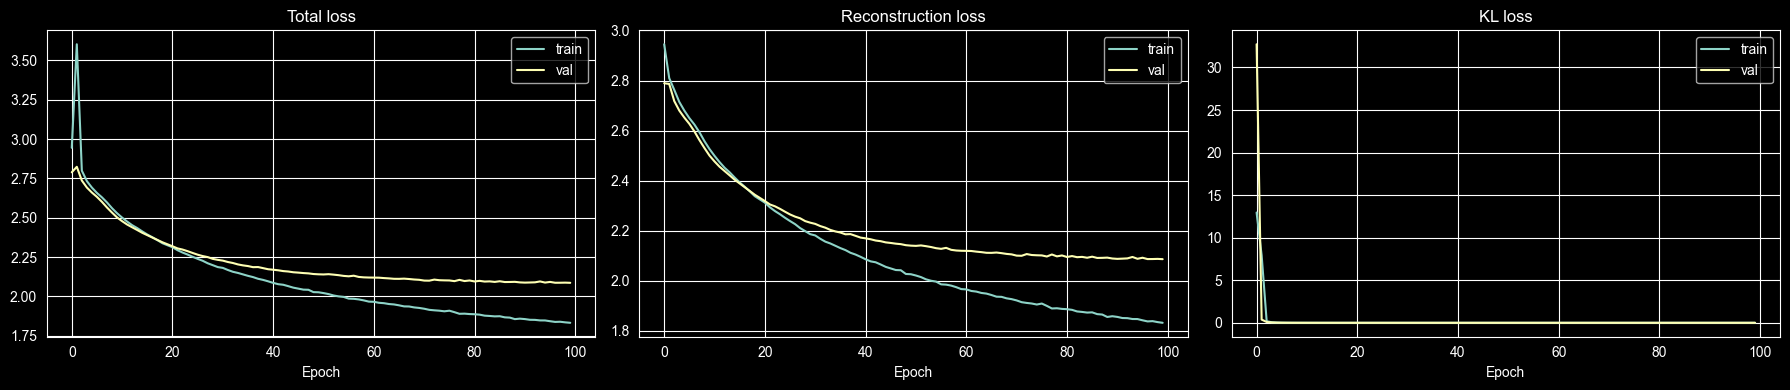

In [8]:
if history is None:
    print("training_history.pkl was not found. Skipping history plots.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    axes[0].plot(history["train_losses"], label="train")
    axes[0].plot(history["val_losses"], label="val")
    axes[0].set_title("Total loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(history["train_recon_losses"], label="train")
    axes[1].plot(history["val_recon_losses"], label="val")
    axes[1].set_title("Reconstruction loss")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    axes[2].plot(history["train_kl_losses"], label="train")
    axes[2].plot(history["val_kl_losses"], label="val")
    axes[2].set_title("KL loss")
    axes[2].set_xlabel("Epoch")
    axes[2].legend()

    plt.tight_layout()
    plt.show()

## 4. Reconstruction and generation utilities

### What these metrics mean

Reconstruction metrics evaluate how well the model can reproduce held-out peptides.
Generation metrics evaluate sampled peptides from the latent space.

These are complementary: strong reconstruction alone does not guarantee useful or diverse generation.

In [9]:
def decode_from_z_cond(model, z, cond_t, max_gen_len=None, temperature=1.0, greedy=False):
    """
    Decode peptide sequences from a latent vector z under a fixed condition vector.

    Temperature controls diversity during sampling.
    Greedy decoding is more deterministic but usually less diverse.
    """
    if max_gen_len is None:
        max_gen_len = max_len

    model.eval()
    with torch.no_grad():
        z_cond = torch.cat([z, cond_t], dim=1)
        h = model.decoder.init_h(z_cond).unsqueeze(0)
        input_token = torch.LongTensor([[SOS_IDX]]).to(device)
        generated = []

        for _ in range(max_gen_len):
            embedded = model.decoder.embedding(input_token)
            z_step = z_cond.unsqueeze(1)
            decoder_input = torch.cat([embedded, z_step], dim=-1)

            output, h = model.decoder.gru(decoder_input, h)
            logits = model.decoder.fc_out(output.squeeze(1))

            if greedy:
                next_token = logits.argmax(dim=-1).item()
            else:
                probs = torch.softmax(logits / temperature, dim=-1)
                next_token = torch.multinomial(probs, 1).item()

            if next_token == EOS_IDX:
                break

            generated.append(next_token)
            input_token = torch.LongTensor([[next_token]]).to(device)

    return detokenize(generated, idx2char)

def generate(model, cond, max_gen_len=None, temperature=0.9, greedy=False):
    cond_t = torch.FloatTensor(cond).unsqueeze(0).to(device)
    z = torch.randn(1, latent_dim).to(device)
    return decode_from_z_cond(model, z, cond_t, max_gen_len=max_gen_len, temperature=temperature, greedy=greedy)

def reconstruct_from_posterior_mean(model, seq, cond_vec):
    tokens = torch.LongTensor([tokenize(seq, char2idx, max_len)]).to(device)
    lengths = torch.LongTensor([min(len(seq) + 2, max_len)]).to(device)
    cond_t = torch.FloatTensor([cond_vec]).to(device)
    with torch.no_grad():
        mu, _ = model.encoder(tokens, lengths, cond_t)
    return decode_from_z_cond(model, mu, cond_t, max_gen_len=max_len, temperature=1.0, greedy=True)

def batch_reconstruction_metrics(model, loader):
    """
    Compute reconstruction quality on a data loader.

    Returns both token-level and sequence-level diagnostics so we can distinguish
    partial reconstruction quality from exact sequence recovery.
    """
    model.eval()
    token_matches = 0
    token_total = 0
    exact_matches = 0
    total = 0
    example_rows = []

    with torch.no_grad():
        for src, lengths, cond in loader:
            src, lengths, cond = src.to(device), lengths.to(device), cond.to(device)
            logits, target, mu, logvar = model(src, lengths, cond)
            pred = logits.argmax(dim=-1)

            mask = target != PAD_IDX
            token_matches += ((pred == target) & mask).sum().item()
            token_total += mask.sum().item()

            exact = (((pred == target) | (~mask))).all(dim=1)
            exact_matches += exact.sum().item()
            total += target.size(0)

            for i in range(target.size(0)):
                if len(example_rows) >= 8:
                    break
                original = detokenize(src[i].detach().cpu().numpy(), idx2char)
                teacher_forced_pred = detokenize(pred[i].detach().cpu().numpy(), idx2char)
                posterior_mean_recon = decode_from_z_cond(
                    model, mu[i:i+1], cond[i:i+1], max_gen_len=max_len, temperature=1.0, greedy=True
                )
                example_rows.append({
                    "original": original,
                    "teacher_forced_argmax": teacher_forced_pred,
                    "posterior_mean_reconstruction": posterior_mean_recon,
                })
            if len(example_rows) >= 8:
                break

    return {
        "token_accuracy": token_matches / max(token_total, 1),
        "exact_match_rate": exact_matches / max(total, 1),
        "examples": pd.DataFrame(example_rows),
    }

def is_valid_peptide(seq, min_len=5, max_len_threshold=None):
    if max_len_threshold is None:
        max_len_threshold = max_len - 2
    return (
        isinstance(seq, str)
        and min_len <= len(seq) <= max_len_threshold
        and all(ch in canonical_aas for ch in seq)
    )

def evaluate_generation(model, cond, num_samples=200, temperature=0.9, reference_set=None):
    generated = [generate(model, cond, temperature=temperature) for _ in range(num_samples)]
    valid = [s for s in generated if is_valid_peptide(s)]

    validity = len(valid) / max(len(generated), 1)
    uniqueness = len(set(valid)) / max(len(valid), 1)
    novelty = None if reference_set is None else np.mean([s not in reference_set for s in valid]) if valid else 0.0
    mean_length = float(np.mean([len(s) for s in valid])) if valid else 0.0

    return {
        "generated": generated,
        "valid_sequences": valid,
        "validity": validity,
        "uniqueness": uniqueness,
        "novelty": novelty,
        "mean_length": mean_length,
    }

def make_condition_vector(column_name):
    vec = np.zeros(len(condition_cols), dtype=np.float32)
    vec[condition_cols.index(column_name)] = 1.0
    return vec.tolist()

condition_vectors = {pretty_condition_names[col]: make_condition_vector(col) for col in condition_cols}
condition_vectors

{'Antibacterial': [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
 'Gram+': [0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0],
 'Gram-': [0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0],
 'Antifungal': [0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0],
 'Antiviral': [0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0],
 'Antiparasitic': [0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0],
 'Anticancer': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0]}

In [10]:
recon_val = batch_reconstruction_metrics(model, val_loader)
recon_test = batch_reconstruction_metrics(model, test_loader)

print("Validation token accuracy :", f"{recon_val['token_accuracy']:.4f}")
print("Validation exact match    :", f"{recon_val['exact_match_rate']:.4f}")
print("Test token accuracy       :", f"{recon_test['token_accuracy']:.4f}")
print("Test exact match          :", f"{recon_test['exact_match_rate']:.4f}")

print("\nReconstruction examples:")
display(recon_test["examples"])

generation_rows = []
generated_by_condition = {}

for cond_name, cond_vec in condition_vectors.items():
    metrics = evaluate_generation(
        model,
        cond_vec,
        num_samples=200,
        temperature=0.9,
        reference_set=full_seqs_set,
    )
    generated_by_condition[cond_name] = metrics["valid_sequences"]
    generation_rows.append({
        "condition": cond_name,
        "validity": metrics["validity"],
        "uniqueness": metrics["uniqueness"],
        "novelty_vs_dataset": metrics["novelty"],
        "mean_length": metrics["mean_length"],
        "num_valid": len(metrics["valid_sequences"]),
    })

generation_metrics_df = pd.DataFrame(generation_rows).sort_values("condition").reset_index(drop=True)
generation_metrics_df

Validation token accuracy : 0.3957
Validation exact match    : 0.0000
Test token accuracy       : 0.4182
Test exact match          : 0.0000

Reconstruction examples:


,original,teacher_forced_argmax,posterior_mean_reconstruction
0,APPPGYAMESDSFS,GKKAALCCVG,GLLSLLKKLLKKL
1,GIFSKFGGKAIKNLFIKGAKNIGKEVGMDVIRTGIDVAGCKIKGEC,GLLSLIGKGGGKGAIKKGGKKVGKEVGKDVIRTGIDVAGQKIKGEC,GLLSLLKKLLKKL
2,GSCGAPISKYDFQVLAKRPPPCRRPRLENTEDVTHTTRP,KLKPEHCCGCCCCCNGNLLNNNPPCNCCRCCCNCCCCCCCPGCGGG...,GLLSGILGAGKHIVCGLSGLC
3,SLTQINTTLLDLTYEMLSLQQVVKALNESYIDLKEL,GIDSTVTYYKDLEEYLKKLEELLTLLEQLLLDLKELGEL,GLPVCGETCFGGTCNTPGCTCSWPVCYRN
4,AGKETIRWFLKKKIWEGKKRATIAW,AGRETIRQKLKKKIEEKKKAAKIAW,AGRQALTLYLKEELRKRGKKAFIAW
5,RRIRPRPRRLPRPRPR,GRIRPRPPPPPRLRPR,KKIGQKIKNFFQKL
6,GVLDILKGAGKDLLAHALSKISEKV,GLFDTLKGAGKALLGHLGGAIACKL,GLLSLLKKLLKKL
7,IAWKGIAAMAKKLL,GNKLLALKLAKKV,GLLSLLKKLLKKL


,condition,validity,uniqueness,novelty_vs_dataset,mean_length,num_valid
0,Antibacterial,1.000,0.995000,0.990000,23.540000,200
1,Anticancer,0.990,1.000000,0.994949,25.222222,198
2,Antifungal,0.970,0.994845,0.989691,25.396907,194
3,Antiparasitic,0.995,0.979899,1.000000,26.507538,199
4,Antiviral,0.865,1.000000,1.000000,25.722543,173
5,Gram+,0.980,1.000000,1.000000,25.260204,196
6,Gram-,0.990,0.959596,0.929293,24.090909,198


## 5. Real vs generated peptide comparison

### Comparing real and generated peptides

This section checks whether generated peptides broadly resemble the empirical AMP distribution rather than only looking valid at the token level.

We compare sequence length and amino-acid composition because these are simple but interpretable diagnostics of distribution alignment.

In [11]:
# Build comparison pools
real_rows = []
generated_rows = []

num_compare_samples = 250

for col in condition_cols:
    cond_name = pretty_condition_names[col]
    real_subset = df[df[col] == 1][seq_col].tolist()
    sampled_real = real_subset[:num_compare_samples]
    if len(real_subset) > num_compare_samples:
        sampled_real = random.sample(real_subset, num_compare_samples)
    # Build matched pools of real and generated peptides for simple side-by-side
    # distribution checks. This is not a formal two-sample test, but a practical diagnostic.
    real_rows.extend([{"condition": cond_name, "source": "real", "sequence": s} for s in sampled_real])

    gen_subset = generated_by_condition.get(cond_name, [])
    gen_subset = gen_subset[:num_compare_samples]
    generated_rows.extend([{"condition": cond_name, "source": "generated", "sequence": s} for s in gen_subset])

comparison_df = pd.DataFrame(real_rows + generated_rows)
comparison_df["length"] = comparison_df["sequence"].str.len()

comparison_df.head()

,condition,source,sequence,length
0,Antibacterial,real,FLPKLFAKITKKNMAHIR,18
1,Antibacterial,real,ARTKQTARKSTGGKAPRKQLAT,22
2,Antibacterial,real,GVFKDALKQFGAALLDKAANALKPK,25
3,Antibacterial,real,GLMDTIKGVAKNVAASLLEKLKCKVTGC,28
4,Antibacterial,real,GLFTLIKGAYKNDAPTVACN,20


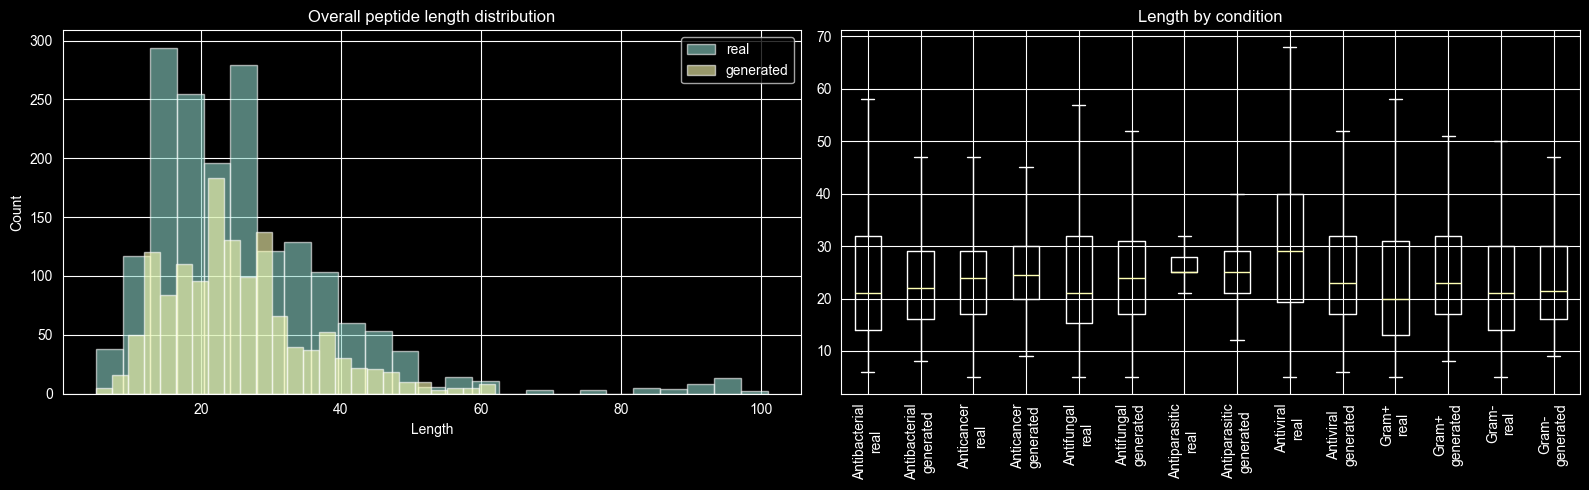

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for source in ["real", "generated"]:
    lengths = comparison_df.loc[comparison_df["source"] == source, "length"]
    axes[0].hist(lengths, bins=25, alpha=0.6, label=source)

axes[0].set_title("Overall peptide length distribution")
axes[0].set_xlabel("Length")
axes[0].set_ylabel("Count")
axes[0].legend()

box_data = []
box_labels = []
for cond_name in sorted(comparison_df["condition"].unique()):
    for source in ["real", "generated"]:
        vals = comparison_df[(comparison_df["condition"] == cond_name) & (comparison_df["source"] == source)]["length"].values
        if len(vals) > 0:
            box_data.append(vals)
            box_labels.append(f"{cond_name}\n{source}")

axes[1].boxplot(box_data, tick_labels=box_labels, showfliers=False)
axes[1].set_title("Length by condition")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

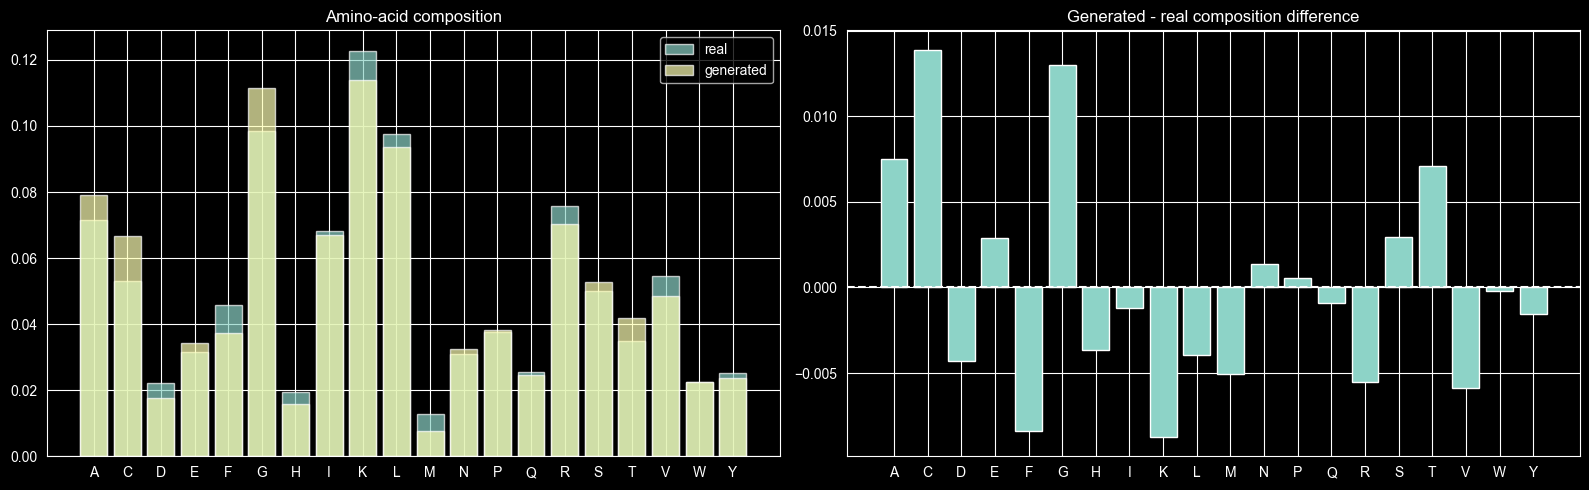

,aa,frequency_real,frequency_generated,difference
0,A,0.071545,0.079061,0.007516
1,C,0.052946,0.066823,0.013878
2,D,0.022042,0.017755,-0.004287
3,E,0.031539,0.034424,0.002885
4,F,0.045795,0.037417,-0.008378
5,G,0.098500,0.111489,0.012990
6,H,0.019410,0.015759,-0.003651
7,I,0.068342,0.067146,-0.001196
8,K,0.122801,0.114072,-0.008729
9,L,0.097622,0.093705,-0.003917


In [24]:
def amino_acid_composition(sequences):
    """
    Compute normalized amino-acid composition over a collection of peptide sequences.
    """
    counts = Counter()
    total = 0
    for seq in sequences:
        counts.update(seq)
        total += len(seq)
    aas = sorted(canonical_aas)
    return pd.DataFrame({
        "aa": aas,
        "frequency": [counts[aa] / max(total, 1) for aa in aas]
    })

real_comp = amino_acid_composition(comparison_df.loc[comparison_df["source"] == "real", "sequence"].tolist())
gen_comp = amino_acid_composition(comparison_df.loc[comparison_df["source"] == "generated", "sequence"].tolist())

comp_merge = real_comp.merge(gen_comp, on="aa", suffixes=("_real", "_generated"))
comp_merge["difference"] = comp_merge["frequency_generated"] - comp_merge["frequency_real"]

# Length and composition are coarse diagnostics:
# they cannot prove biological realism, but they quickly reveal obvious mismatch.
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].bar(comp_merge["aa"], comp_merge["frequency_real"], alpha=0.7, label="real")
axes[0].bar(comp_merge["aa"], comp_merge["frequency_generated"], alpha=0.7, label="generated")
axes[0].set_title("Amino-acid composition")
axes[0].legend()

axes[1].bar(comp_merge["aa"], comp_merge["difference"])
axes[1].axhline(0, linestyle="--")
axes[1].set_title("Generated - real composition difference")

plt.tight_layout()
plt.show()

comp_merge

## 6. Physicochemical properties

### Why physicochemical properties matter

AMP quality cannot be judged only by syntax.
Many antimicrobial peptides are characterized by interpretable global properties such as charge, hydrophobicity, hydrophobic moment, and sequence length.

These features do not prove activity, but they help assess whether generated peptides remain in a biologically plausible regime.

In [25]:
KD_SCALE = {
    "A": 1.8, "C": 2.5, "D": -3.5, "E": -3.5, "F": 2.8,
    "G": -0.4, "H": -3.2, "I": 4.5, "K": -3.9, "L": 3.8,
    "M": 1.9, "N": -3.5, "P": -1.6, "Q": -3.5, "R": -4.5,
    "S": -0.8, "T": -0.7, "V": 4.2, "W": -0.9, "Y": -1.3,
}
HYDROPHOBIC_APD = set("AILMFWVCP")
AROMATIC = set("FWY")

def net_charge(seq):
    """Approximate peptide net charge from residue composition."""
    charge = 0.0
    for aa in seq:
        if aa in {"K", "R"}:
            charge += 1.0
        elif aa == "H":
            charge += 0.1
        elif aa in {"D", "E"}:
            charge -= 1.0
    return charge

def hydrophobic_ratio_apd(seq):
    return np.mean([aa in HYDROPHOBIC_APD for aa in seq]) if seq else 0.0

def mean_hydrophobicity(seq):
    """Approximate mean hydrophobicity using the Kyte–Doolittle scale."""
    return float(np.mean([KD_SCALE.get(aa, 0.0) for aa in seq])) if seq else 0.0

def aromatic_fraction(seq):
    return np.mean([aa in AROMATIC for aa in seq]) if seq else 0.0

def hydrophobic_moment(seq, angle_deg=100.0):
    """
    Approximate hydrophobic moment under an alpha-helical assumption.

    This is a rough physicochemical proxy, not a structural prediction.
    """
    if not seq:
        return 0.0
    angle = math.radians(angle_deg)
    x = sum(KD_SCALE.get(aa, 0.0) * math.cos(i * angle) for i, aa in enumerate(seq))
    y = sum(KD_SCALE.get(aa, 0.0) * math.sin(i * angle) for i, aa in enumerate(seq))
    return math.sqrt(x * x + y * y) / len(seq)

def compute_properties(sequences, source_name, condition_name):
    rows = []
    for seq in sequences:
        rows.append({
            "sequence": seq,
            "source": source_name,
            "condition": condition_name,
            "length": len(seq),
            "net_charge": net_charge(seq),
            "hydrophobic_ratio_apd": hydrophobic_ratio_apd(seq),
            "mean_hydrophobicity": mean_hydrophobicity(seq),
            "aromatic_fraction": aromatic_fraction(seq),
            "hydrophobic_moment": hydrophobic_moment(seq),
        })
    return pd.DataFrame(rows)

property_frames = []
for col in condition_cols:
    cond_name = pretty_condition_names[col]
    real_seqs = comparison_df[(comparison_df["condition"] == cond_name) & (comparison_df["source"] == "real")]["sequence"].tolist()
    gen_seqs = comparison_df[(comparison_df["condition"] == cond_name) & (comparison_df["source"] == "generated")]["sequence"].tolist()

    property_frames.append(compute_properties(real_seqs, "real", cond_name))
    property_frames.append(compute_properties(gen_seqs, "generated", cond_name))

# Compute the same feature set for real and generated peptides so their
# distributions can be compared directly.
properties_df = pd.concat(property_frames, ignore_index=True)
properties_df.head()

,sequence,source,condition,length,net_charge,hydrophobic_ratio_apd,mean_hydrophobicity,aromatic_fraction,hydrophobic_moment
0,FLPKLFAKITKKNMAHIR,real,Antibacterial,18,5.1,0.555556,-0.077778,0.111111,1.022786
1,ARTKQTARKSTGGKAPRKQLAT,real,Antibacterial,22,7.0,0.272727,-1.413636,0.000000,0.184557
2,GVFKDALKQFGAALLDKAANALKPK,real,Antibacterial,25,3.0,0.560000,-0.004000,0.080000,0.837480
3,GLMDTIKGVAKNVAASLLEKLKCKVTGC,real,Antibacterial,28,3.0,0.500000,0.400000,0.000000,1.053837
4,GLFTLIKGAYKNDAPTVACN,real,Antibacterial,20,1.0,0.500000,0.180000,0.100000,0.596736


In [26]:
summary_props = (
    properties_df.groupby(["source", "condition"])[
        ["length", "net_charge", "hydrophobic_ratio_apd", "mean_hydrophobicity", "aromatic_fraction", "hydrophobic_moment"]
    ]
    .agg(["mean", "std"])
)

summary_props

length            net_charge            \
                              mean        std       mean       std   
source    condition                                                  
generated Antibacterial  23.540000   9.501039   3.632500  2.560817   
          Anticancer     25.222222   8.426518   1.952525  2.292953   
          Antifungal     25.396907  11.883815   3.468557  2.924630   
          Antiparasitic  26.507538   7.863012   5.805528  2.634718   
          Antiviral      25.722543  11.594576   0.801734  3.578220   
          Gram+          25.260204  10.776453   2.604082  2.159270   
          Gram-          24.090909  10.539836   4.890404  3.048551   
real      Antibacterial  23.428000  10.863373   4.216000  3.117006   
          Anticancer     24.188000   9.452941   3.165200  2.801625   
          Antifungal     25.164000  12.344173   4.170800  2.849601   
          Antiparasitic  28.264000  12.203853   4.862400  3.344567   
          Antiviral      35.208000  23.746248   1.948800  3.594297   
          Gram+          23.048000  11.284817   3.977200  3.123714   
          Gram-          23.076000  11.060904   4.465600  2.819129   

                        hydrophobic_ratio_apd           mean_hydrophobicity  \
                                         mean       std                mean   
source    condition                                                           
generated Antibacterial              0.462232  0.118761           -0.098131   
          Anticancer                 0.515250  0.101815            0.426455   
          Antifungal                 0.415899  0.140926           -0.512984   
          Antiparasitic              0.420622  0.083805           -0.684981   
          Antiviral                  0.489522  0.118790            0.230083   
          Gram+                      0.534548  0.123811            0.541755   
          Gram-                      0.478654  0.104545           -0.445344   
real      Antibacterial              0.493227  0.139328           -0.107017   
          Anticancer                 0.533431  0.119615            0.414873   
          Antifungal                 0.451314  0.155332           -0.276778   
          Antiparasitic              0.453094  0.096549           -0.418996   
          Antiviral                  0.466910  0.124759            0.005513   
          Gram+                      0.497221  0.134231            0.044292   
          Gram-                      0.477863  0.140514           -0.250710   

                                  aromatic_fraction            \
                              std              mean       std   
source    condition                                             
generated Antibacterial  0.903761          0.076528  0.076862   
          Anticancer     0.778798          0.062387  0.058556   
          Antifungal     0.938477          0.097631  0.070025   
          Antiparasitic  0.595223          0.106651  0.053557   
          Antiviral      0.860528          0.096045  0.075914   
          Gram+          0.799521          0.089225  0.068261   
          Gram-          1.031872          0.080192  0.074229   
real      Antibacterial  0.966193          0.110531  0.100209   
          Anticancer     0.798945          0.083850  0.071183   
          Antifungal     1.013496          0.106296  0.087795   
          Antiparasitic  0.808981          0.100380  0.048008   
          Antiviral      0.777882          0.097304  0.072580   
          Gram+          1.024095          0.108030  0.095689   
          Gram-          1.014773          0.109276  0.092924   

                        hydrophobic_moment            
                                      mean       std  
source    condition                                   
generated Antibacterial           0.984826  0.563786  
          Anticancer              0.877320  0.577585  
          Antifungal              0.806163  0.562373  
          Antiparasitic           0.925313  0.451668  
  

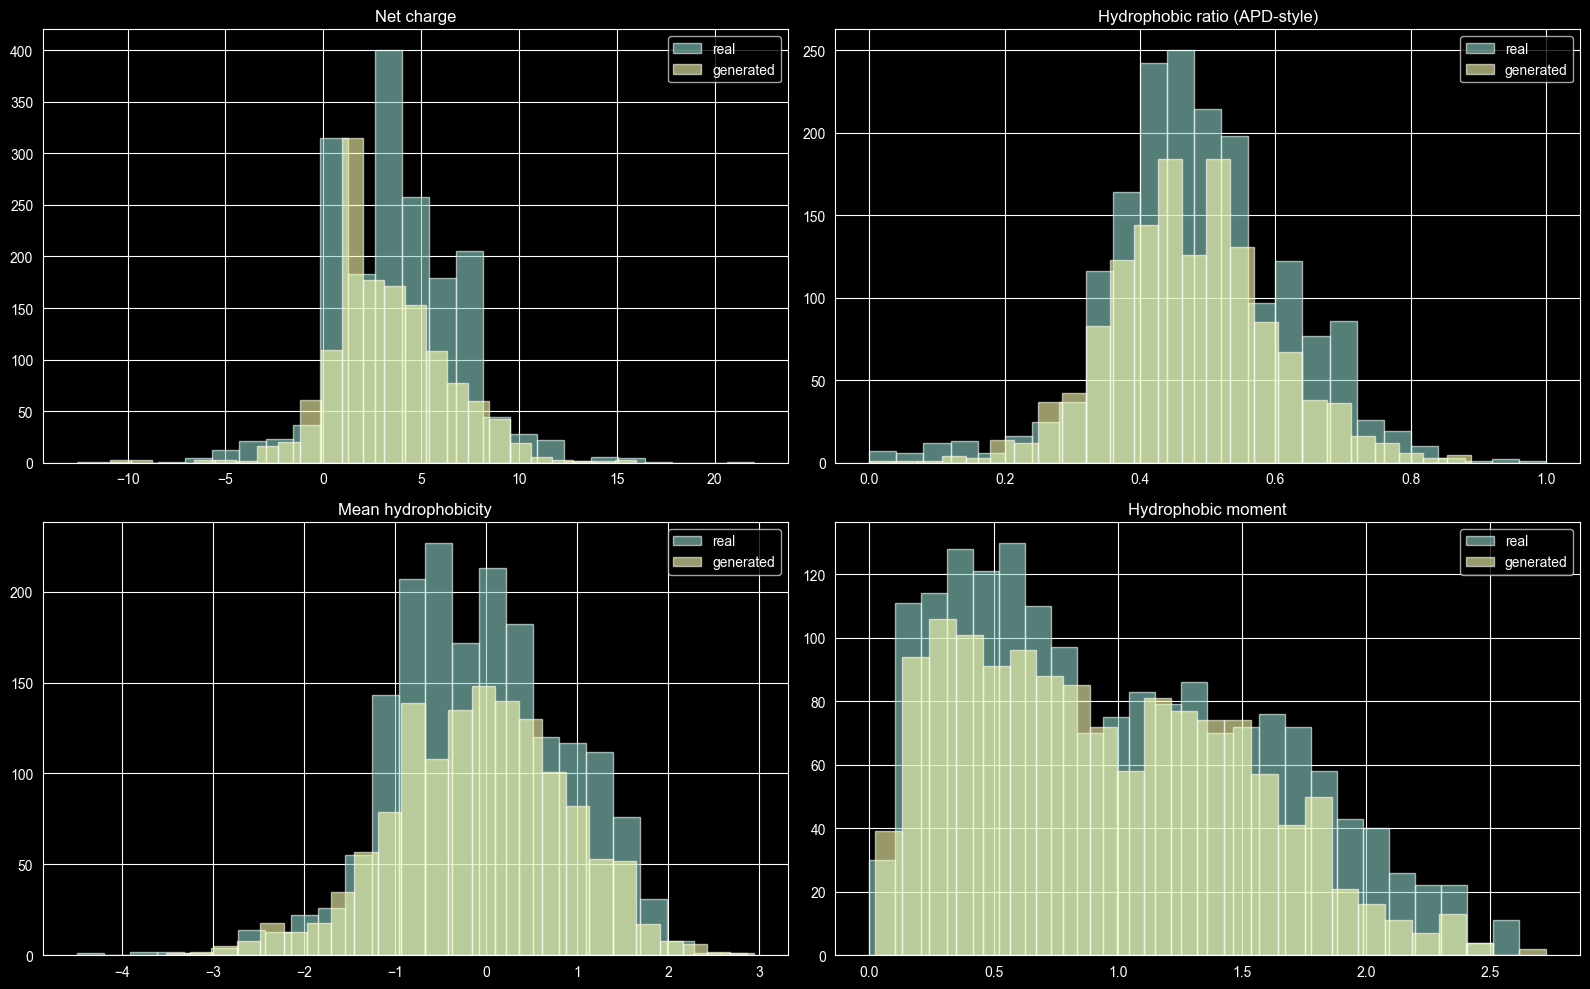

In [27]:
plot_specs = [
    ("net_charge", "Net charge"),
    ("hydrophobic_ratio_apd", "Hydrophobic ratio (APD-style)"),
    ("mean_hydrophobicity", "Mean hydrophobicity"),
    ("hydrophobic_moment", "Hydrophobic moment"),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

for ax, (col, title) in zip(axes, plot_specs):
    real_vals = properties_df.loc[properties_df["source"] == "real", col]
    gen_vals = properties_df.loc[properties_df["source"] == "generated", col]
    ax.hist(real_vals, bins=25, alpha=0.6, label="real")
    ax.hist(gen_vals, bins=25, alpha=0.6, label="generated")
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

## 7. Latent space analysis with t-SNE

### Interpreting t-SNE carefully

t-SNE is used here as a visualization tool, not as a quantitative metric.
It is useful for revealing local structure and coarse clustering tendencies, but distances in 2D should not be overinterpreted as exact distances in the original latent space.

In [28]:
def get_latent_vectors(model, loader):
    """
    Extract encoder mean vectors for downstream latent-space visualization.

    We use the posterior mean rather than random samples to obtain a more stable
    representation of each peptide in latent space.
    """
    model.eval()
    latents = []
    conds = []
    seqs = []
    lengths_list = []

    with torch.no_grad():
        for src, lengths, cond in loader:
            src, lengths, cond = src.to(device), lengths.to(device), cond.to(device)
            mu, _ = model.encoder(src, lengths, cond)
            latents.append(mu.cpu().numpy())
            conds.append(cond.cpu().numpy())
            seqs.extend([detokenize(x.cpu().numpy(), idx2char) for x in src])
            lengths_list.extend([int(x.item()) - 2 for x in lengths.cpu()])

    return (
        np.vstack(latents),
        np.vstack(conds),
        seqs,
        np.array(lengths_list),
    )

real_latents, real_conds, real_sequences, real_lengths_eval = get_latent_vectors(model, test_loader)

real_latent_df = pd.DataFrame(real_conds, columns=condition_cols)
real_latent_df["sequence"] = real_sequences
real_latent_df["length"] = real_lengths_eval
real_latent_df["label"] = real_latent_df[condition_cols].apply(
    lambda row: "Multi" if row.sum() > 1 else (
        pretty_condition_names[row.index[row.values == 1][0]] if row.sum() == 1 else "None"
    ),
    axis=1
)

real_latent_df.head()

,is_antibacterial,is_anti_gram_positive,is_anti_gram_negative,is_antifungal,is_antiviral,is_antiparasitic,is_anticancer,sequence,length,label
0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,APPPGYAMESDSFS,14,Multi
1,1.0,1.0,1.0,0.0,0.0,0.0,0.0,GIFSKFGGKAIKNLFIKGAKNIGKEVGMDVIRTGIDVAGCKIKGEC,46,Multi
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,GSCGAPISKYDFQVLAKRPPPCRRPRLENTEDVTHTTRP,39,Antifungal
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,SLTQINTTLLDLTYEMLSLQQVVKALNESYIDLKEL,36,Antiviral
4,0.0,0.0,0.0,0.0,0.0,1.0,0.0,AGKETIRWFLKKKIWEGKKRATIAW,25,Antiparasitic


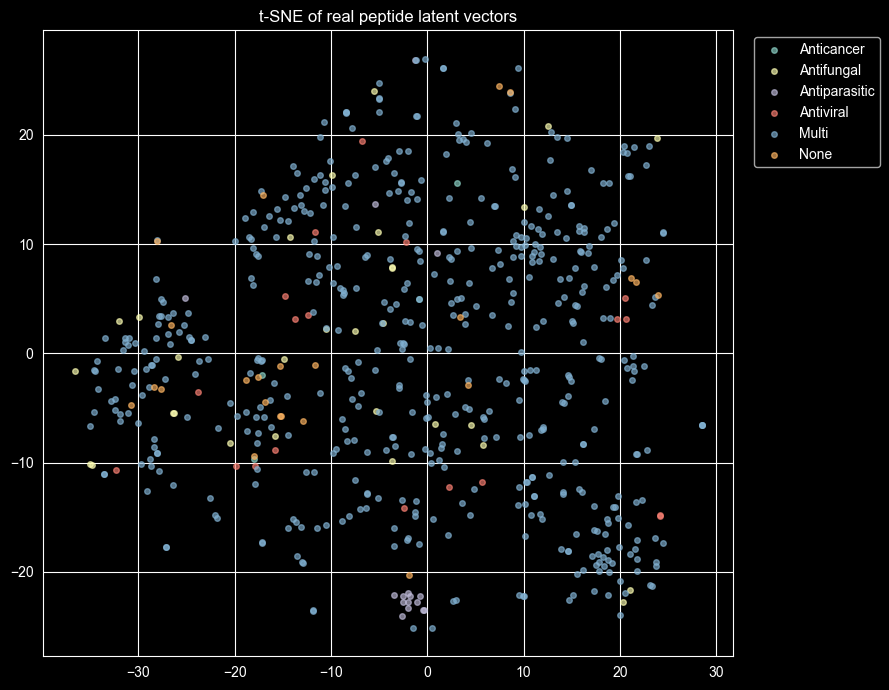

In [29]:
# Subsample large point clouds to keep t-SNE computation manageable
# and visualizations readable.
TSNE_REAL_SUBSAMPLE = min(2000, len(real_latents))
real_idx = np.random.choice(len(real_latents), size=TSNE_REAL_SUBSAMPLE, replace=False)

real_latents_sub = real_latents[real_idx]
real_df_sub = real_latent_df.iloc[real_idx].reset_index(drop=True)

latent_for_tsne = real_latents_sub
if latent_for_tsne.shape[1] > 20:
    latent_for_tsne = PCA(n_components=min(20, latent_for_tsne.shape[1]), random_state=SEED).fit_transform(latent_for_tsne)

tsne_real = TSNE(
    n_components=2,
    perplexity=min(30, max(5, len(latent_for_tsne) // 20)),
    init="pca",
    learning_rate="auto",
    random_state=SEED,
)
real_2d = tsne_real.fit_transform(latent_for_tsne)

real_df_sub["tsne_1"] = real_2d[:, 0]
real_df_sub["tsne_2"] = real_2d[:, 1]

fig, ax = plt.subplots(figsize=(9, 7))
# This comparison asks whether conditional generations move in the expected
# direction in latent space, not whether they perfectly match the real density.
for label in sorted(real_df_sub["label"].unique()):
    part = real_df_sub[real_df_sub["label"] == label]
    ax.scatter(part["tsne_1"], part["tsne_2"], s=16, alpha=0.65, label=label)

ax.set_title("t-SNE of real peptide latent vectors")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 8. Compare real and generated peptides in latent space

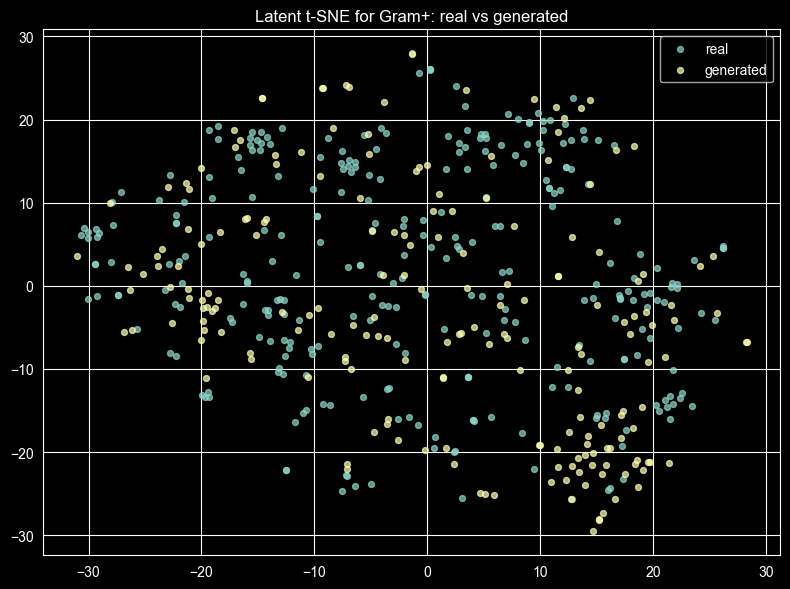

In [19]:
# Choose one condition to inspect whether generated peptides occupy
# a plausible region relative to real peptides with the same label profile.
SELECTED_CONDITION = "Gram+"  # change if needed
selected_col = {v: k for k, v in pretty_condition_names.items()}[SELECTED_CONDITION]
selected_vec = condition_vectors[SELECTED_CONDITION]

generated_selected = generated_by_condition[SELECTED_CONDITION][:300]
real_selected = df[df[selected_col] == 1][seq_col].tolist()[:300]

def encode_sequences_with_condition(model, sequences, cond_vector):
    if len(sequences) == 0:
        return np.empty((0, latent_dim))
    tokens = [tokenize(s, char2idx, max_len) for s in sequences]
    lengths = [min(len(s) + 2, max_len) for s in sequences]
    conds = np.repeat(np.array(cond_vector, dtype=np.float32)[None, :], len(sequences), axis=0)

    tmp_dataset = AMPDataset(tokens, lengths, conds)
    tmp_loader = DataLoader(tmp_dataset, batch_size=256, shuffle=False)

    latents = []
    with torch.no_grad():
        for src, lengths, cond in tmp_loader:
            src, lengths, cond = src.to(device), lengths.to(device), cond.to(device)
            mu, _ = model.encoder(src, lengths, cond)
            latents.append(mu.cpu().numpy())
    return np.vstack(latents) if latents else np.empty((0, latent_dim))

real_cond_latents = encode_sequences_with_condition(model, real_selected, selected_vec)
gen_cond_latents = encode_sequences_with_condition(model, generated_selected, selected_vec)

combined_latents = np.vstack([real_cond_latents, gen_cond_latents])
combined_source = (["real"] * len(real_cond_latents)) + (["generated"] * len(gen_cond_latents))

tsne_input = combined_latents
if tsne_input.shape[1] > 20:
    tsne_input = PCA(n_components=min(20, tsne_input.shape[1]), random_state=SEED).fit_transform(tsne_input)

combined_2d = TSNE(
    n_components=2,
    perplexity=min(30, max(5, len(tsne_input) // 20)),
    init="pca",
    learning_rate="auto",
    random_state=SEED,
).fit_transform(tsne_input)

latent_compare_df = pd.DataFrame({
    "tsne_1": combined_2d[:, 0],
    "tsne_2": combined_2d[:, 1],
    "source": combined_source,
})

fig, ax = plt.subplots(figsize=(8, 6))
for source in ["real", "generated"]:
    part = latent_compare_df[latent_compare_df["source"] == source]
    ax.scatter(part["tsne_1"], part["tsne_2"], s=18, alpha=0.7, label=source)

ax.set_title(f"Latent t-SNE for {SELECTED_CONDITION}: real vs generated")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Interpolation trajectories

`t-SNE` is useful for visualization, but distances and paths in `t-SNE` space should be treated as approximate.  
The interpolation itself is performed linearly in the original latent space.

In [30]:
def encode_single_sequence(model, seq, cond_vec):
    """
    Encode a single peptide into the latent posterior mean under a fixed condition.
    """
    tokens = torch.LongTensor([tokenize(seq, char2idx, max_len)]).to(device)
    lengths = torch.LongTensor([min(len(seq) + 2, max_len)]).to(device)
    cond_t = torch.FloatTensor([cond_vec]).to(device)
    with torch.no_grad():
        mu, _ = model.encoder(tokens, lengths, cond_t)
    return mu.squeeze(0), cond_t

def interpolate_sequences(model, seq_a, seq_b, cond_vec, steps=8):
    """
    Create a linear interpolation path between two latent vectors.

    This is used to inspect whether the decoder changes peptide sequences
    smoothly when moving through latent space.
    """
    z_a, cond_t = encode_single_sequence(model, seq_a, cond_vec)
    z_b, _ = encode_single_sequence(model, seq_b, cond_vec)

    alphas = np.linspace(0.0, 1.0, steps)
    latent_points = []
    decoded_sequences = []

    for alpha in alphas:
        z = (1 - alpha) * z_a + alpha * z_b
        latent_points.append(z.detach().cpu().numpy())
        decoded_seq = decode_from_z_cond(
            model,
            z.unsqueeze(0).to(device),
            cond_t,
            max_gen_len=max_len,
            temperature=1.0,
            greedy=True,
        )
        decoded_sequences.append(decoded_seq)

    return np.vstack(latent_points), decoded_sequences, alphas

INTERP_CONDITION = SELECTED_CONDITION
interp_col = {v: k for k, v in pretty_condition_names.items()}[INTERP_CONDITION]
interp_vec = condition_vectors[INTERP_CONDITION]

interp_pool = df[df[interp_col] == 1][seq_col].tolist()
interp_pool = [s for s in interp_pool if 8 <= len(s) <= (max_len - 2)]
print("Interpolation pool size:", len(interp_pool))

Interpolation pool size: 4078


,trajectory_id,alpha,decoded_sequence,start_seq,end_seq
0,0,0.000000,GLLSGILGAGKKIVCGLSGLC,GFMDTAKNVFKNVAVTLLDKLKCKIAGGC,FIGAVKGLLSKIF
1,0,0.142857,GLLSGILGAGKKIVCGLSGLC,GFMDTAKNVFKNVAVTLLDKLKCKIAGGC,FIGAVKGLLSKIF
2,0,0.285714,GLLSGILGAGKKIVCGLSGLC,GFMDTAKNVFKNVAVTLLDKLKCKIAGGC,FIGAVKGLLSKIF
3,0,0.428571,GLLSGILGAGKKIVCGLSGLC,GFMDTAKNVFKNVAVTLLDKLKCKIAGGC,FIGAVKGLLSKIF
4,0,0.571429,GLLSGILGAGKKIVCGLSGLC,GFMDTAKNVFKNVAVTLLDKLKCKIAGGC,FIGAVKGLLSKIF
5,0,0.714286,GLLSGILGAGKKIVCGLSGLC,GFMDTAKNVFKNVAVTLLDKLKCKIAGGC,FIGAVKGLLSKIF
6,0,0.857143,GLLSGILGAGKKIVCGLSGLC,GFMDTAKNVFKNVAVTLLDKLKCKIAGGC,FIGAVKGLLSKIF
7,0,1.000000,GLLSGILGAGKKIVCGLSGLC,GFMDTAKNVFKNVAVTLLDKLKCKIAGGC,FIGAVKGLLSKIF
8,1,0.000000,GLLSGILGAGKKIVCGLSGLC,ATCDLLSGFGVGDSACAAHCIARGNRGGYCNSQKVCVCRN,FWGALIKGAAKLIPSVVGLFKKKQ
9,1,0.142857,GLLSGILGAGKKIVCGLSGLC,ATCDLLSGFGVGDSACAAHCIARGNRGGYCNSQKVCVCRN,FWGALIKGAAKLIPSVVGLFKKKQ


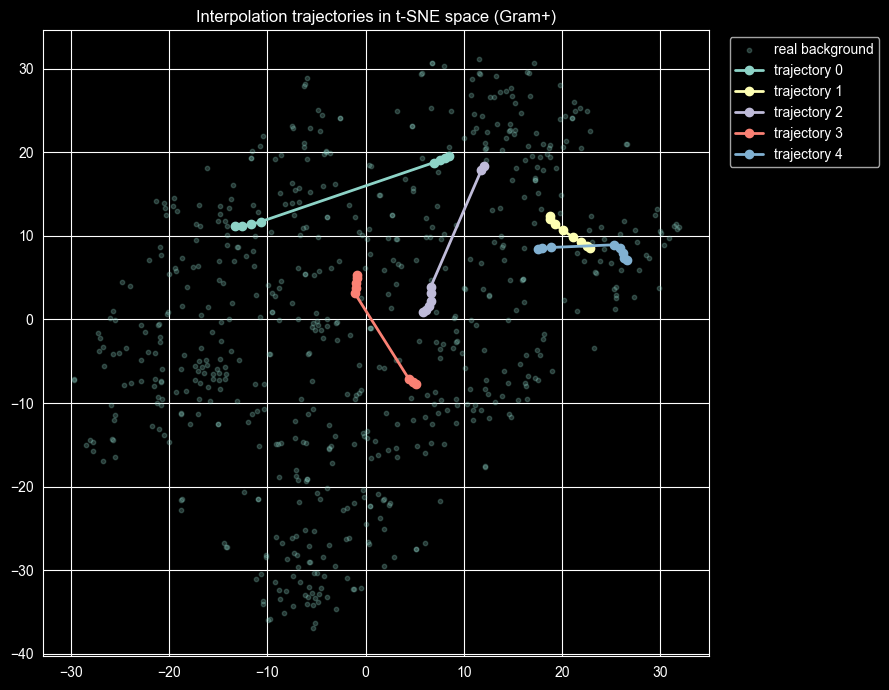

In [31]:
# Keep only a few example trajectories so the visualization remains interpretable.
num_trajectories = min(5, max(1, len(interp_pool) // 2))
trajectory_records = []
all_interp_latents = []

# Interpolation plots are qualitative diagnostics of latent smoothness.
# They help assess whether nearby latent points decode to gradually changing peptides.
if len(interp_pool) < 2:
    print("Not enough sequences for interpolation trajectories.")
else:
    sampled = random.sample(interp_pool, k=min(len(interp_pool), num_trajectories * 2))
    trajectory_tables = []

    for t in range(num_trajectories):
        seq_a = sampled[2 * t]
        seq_b = sampled[2 * t + 1]
        latents_path, decoded_path, alphas = interpolate_sequences(model, seq_a, seq_b, interp_vec, steps=8)

        all_interp_latents.append(latents_path)

        traj_df = pd.DataFrame({
            "trajectory_id": t,
            "alpha": alphas,
            "decoded_sequence": decoded_path,
        })
        traj_df["start_seq"] = seq_a
        traj_df["end_seq"] = seq_b
        trajectory_tables.append(traj_df)

        for step_idx, alpha in enumerate(alphas):
            trajectory_records.append({
                "trajectory_id": t,
                "alpha": float(alpha),
                "sequence": decoded_path[step_idx],
            })

    interp_sequences_df = pd.concat(trajectory_tables, ignore_index=True)
    display(interp_sequences_df.head(16))

    interp_latents = np.vstack(all_interp_latents)
    base_real = real_latents_sub[: min(1000, len(real_latents_sub))]
    combined_interp = np.vstack([base_real, interp_latents])

    tsne_input = combined_interp
    if tsne_input.shape[1] > 20:
        tsne_input = PCA(n_components=min(20, tsne_input.shape[1]), random_state=SEED).fit_transform(tsne_input)

    combined_interp_2d = TSNE(
        n_components=2,
        perplexity=min(30, max(5, len(tsne_input) // 20)),
        init="pca",
        learning_rate="auto",
        random_state=SEED,
    ).fit_transform(tsne_input)

    real_base_2d = combined_interp_2d[: len(base_real)]
    interp_2d = combined_interp_2d[len(base_real):]

    fig, ax = plt.subplots(figsize=(9, 7))
    ax.scatter(real_base_2d[:, 0], real_base_2d[:, 1], s=10, alpha=0.25, label="real background")

    cursor = 0
    for t in range(num_trajectories):
        path_2d = interp_2d[cursor: cursor + 8]
        ax.plot(path_2d[:, 0], path_2d[:, 1], marker="o", linewidth=2, label=f"trajectory {t}")
        cursor += 8

    ax.set_title(f"Interpolation trajectories in t-SNE space ({INTERP_CONDITION})")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

## 10. Save summary artifacts

### Exported outputs

The tables saved below are intended for the final report.
They make it easier to reuse the same numerical summaries and avoid manual copy-paste from notebook output cells.

In [32]:
# Export compact analysis tables so the report can cite stable outputs
# rather than screenshots from notebook cells.
generation_metrics_df.to_csv(OUTPUT_DIR / "generation_metrics.csv", index=False)
comparison_df.to_csv(OUTPUT_DIR / "real_vs_generated_sequences.csv", index=False)
properties_df.to_csv(OUTPUT_DIR / "physicochemical_properties.csv", index=False)

summary = {
    "reconstruction_val": {
        "token_accuracy": recon_val["token_accuracy"],
        "exact_match_rate": recon_val["exact_match_rate"],
    },
    "reconstruction_test": {
        "token_accuracy": recon_test["token_accuracy"],
        "exact_match_rate": recon_test["exact_match_rate"],
    },
    "generation_metrics_path": str((OUTPUT_DIR / "generation_metrics.csv").resolve()),
    "comparison_sequences_path": str((OUTPUT_DIR / "real_vs_generated_sequences.csv").resolve()),
    "physicochemical_properties_path": str((OUTPUT_DIR / "physicochemical_properties.csv").resolve()),
}

with open(OUTPUT_DIR / "analysis_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

summary

{'reconstruction_val': {'token_accuracy': 0.3957322987390883,
  'exact_match_rate': 0.0},
 'reconstruction_test': {'token_accuracy': 0.4181604466647076,
  'exact_match_rate': 0.0},
 'generation_metrics_path': 'C:\\Users\\artem\\Study\\AMPs-via-VAE\\model_training\\notebooks\\analysis_outputs\\generation_metrics.csv',
 'comparison_sequences_path': 'C:\\Users\\artem\\Study\\AMPs-via-VAE\\model_training\\notebooks\\analysis_outputs\\real_vs_generated_sequences.csv',
 'physicochemical_properties_path': 'C:\\Users\\artem\\Study\\AMPs-via-VAE\\model_training\\notebooks\\analysis_outputs\\physicochemical_properties.csv'}